In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
customer_data=pd.read_csv("retail_customer_segmentation.csv")

In [3]:
customer_data.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,2.0,Card,Semi-Urban,Occasional
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,2.0,Wallet,Urban,Occasional
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,1.0,UPI,Rural,Occasional
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,0.0,Wallet,Rural,High_Value
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,1.0,Card,Semi-Urban,Occasional


In [4]:
customer_data.shape

(50000, 14)

In [5]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  int64  
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  str    
 12  region                 50000 non-null  str    
 13  customer_segment       50000 non-null  str    
dtypes: float64(7), int64(4), str(3)
memory usage: 5.3 MB


In [6]:
customer_data.isna().sum()

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [7]:
annual_income_median=customer_data['annual_income'].median()
avg_monthly_spend=customer_data['avg_monthly_spend'].median()
purchase_frequency=customer_data['purchase_frequency'].median()
discount_usage_rate=customer_data['discount_usage_rate'].median()
return_rate=customer_data['return_rate'].median()
browsing_time_minutes=customer_data['browsing_time_minutes'].median()
support_interactions=customer_data['support_interactions'].median()


In [8]:
customer_data['annual_income'].mean()

np.float64(44542.61984017048)

In [9]:
customer_data.describe()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,46925.000000,50000.000000,47480.000000,48021.000000,50000.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,25000.500000,44.002820,44542.619840,36.477480,337.294861,4.910643,77.375680,0.284356,0.147553,61.780923,1.494606
std,14433.901067,15.269871,30537.946409,20.787197,204.628556,3.430665,70.534023,0.162170,0.116261,41.745587,1.221280
min,1.000000,18.000000,2946.000000,1.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,31.000000,24373.000000,18.000000,192.000000,2.000000,32.000000,0.200000,0.100000,31.000000,1.000000
50%,25000.500000,44.000000,36788.000000,36.000000,297.000000,4.000000,57.000000,0.300000,0.100000,53.000000,1.000000
75%,37500.250000,57.000000,55497.000000,55.000000,439.000000,7.000000,99.000000,0.400000,0.200000,83.000000,2.000000
max,50000.000000,70.000000,530788.000000,72.000000,3026.000000,68.000000,1289.000000,0.900000,0.800000,407.000000,9.000000


In [10]:
fill_values = {
    'annual_income': annual_income_median,
    'avg_monthly_spend':avg_monthly_spend,
    'purchase_frequency':purchase_frequency,
    'discount_usage_rate':discount_usage_rate,
    'return_rate':return_rate,
    'browsing_time_minutes':browsing_time_minutes,
    'support_interactions':support_interactions,
}

In [11]:
customer_data=customer_data.fillna(fill_values)

In [12]:
customer_data.isna().sum()

customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [13]:
customer_data.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,2.0,Card,Semi-Urban,Occasional
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,2.0,Wallet,Urban,Occasional
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,1.0,UPI,Rural,Occasional
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,0.0,Wallet,Rural,High_Value
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,1.0,Card,Semi-Urban,Occasional


In [14]:
x=customer_data.drop(['customer_segment'],axis=1)

In [15]:
x.shape

(50000, 13)

In [16]:
x.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,2.0,Card,Semi-Urban
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,2.0,Wallet,Urban
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,1.0,UPI,Rural
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,0.0,Wallet,Rural
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,1.0,Card,Semi-Urban


In [17]:
y=customer_data['customer_segment']

In [18]:
y.shape

(50000,)

In [19]:
y.head()

0    Occasional
1    Occasional
2    Occasional
3    High_Value
4    Occasional
Name: customer_segment, dtype: str

In [20]:
y.unique()

<StringArray>
['Occasional', 'High_Value', 'Loyal', 'Regular']
Length: 4, dtype: str

In [21]:
y=y.map({'Occasional':1,'High_Value':2,'Loyal':3,'Regular':4})

In [22]:
y.head()

0    1
1    1
2    1
3    2
4    1
Name: customer_segment, dtype: int64

In [23]:
le=LabelEncoder()

In [24]:
cat_columns=x.select_dtypes(include="str").columns

In [25]:
for col in cat_columns:
    x[col]=le.fit_transform(x[col])

In [26]:
x.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,2.0,0,1
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,2.0,2,2
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,1.0,1,0
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,0.0,2,0
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,1.0,0,1


In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [28]:
corr_df=pd.concat([x,y],axis=1)
corr_matrix=corr_df.corr()

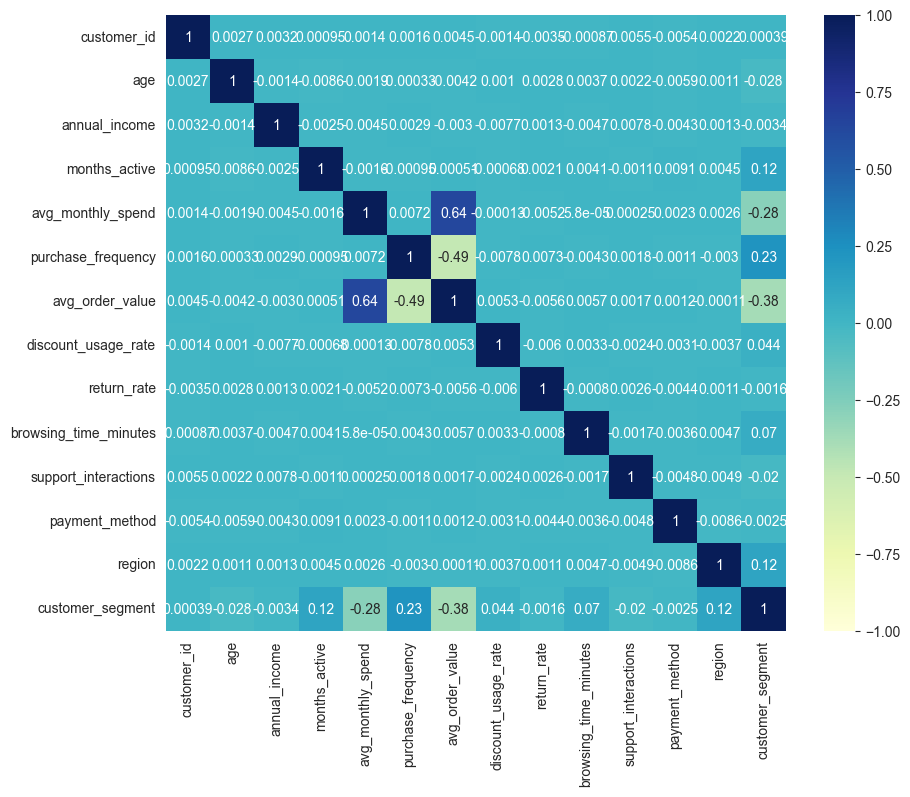

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="YlGnBu",vmin=-1,vmax=1)
plt.show()

In [30]:
mi=mutual_info_classif(x_train,y_train)
mi_scores=pd.Series(mi,index=x.columns).sort_values(ascending=False)
mi_scores

purchase_frequency       0.211852
avg_order_value          0.167955
months_active            0.135445
avg_monthly_spend        0.081399
browsing_time_minutes    0.006518
region                   0.006267
return_rate              0.002014
discount_usage_rate      0.001749
age                      0.000275
annual_income            0.000000
customer_id              0.000000
support_interactions     0.000000
payment_method           0.000000
dtype: float64

In [31]:
model=RandomForestClassifier(class_weight='balanced')
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
importance=pd.Series(model.feature_importances_,index=x.columns).sort_values(ascending=False)
importance

months_active            0.193407
purchase_frequency       0.184912
avg_monthly_spend        0.141118
avg_order_value          0.137740
customer_id              0.059557
browsing_time_minutes    0.059086
annual_income            0.058746
age                      0.052913
discount_usage_rate      0.030514
support_interactions     0.026540
return_rate              0.023698
region                   0.016008
payment_method           0.015760
dtype: float64

In [34]:
x_train.drop(['customer_id','annual_income','age','discount_usage_rate','support_interactions', 'return_rate', 'region', 'payment_method'],axis=1,inplace=True)

In [35]:
x_train.head()

,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,browsing_time_minutes
38094,32,584.0,4.0,114,47.0
40624,38,182.0,4.0,36,84.0
49425,28,297.0,4.0,66,15.0
35734,71,311.0,0.0,214,89.0
41708,10,285.0,8.0,32,15.0


In [36]:
x_test.drop(['customer_id','annual_income','age','discount_usage_rate','support_interactions', 'return_rate', 'region', 'payment_method'],axis=1,inplace=True)

In [37]:
x_test.head()

,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,browsing_time_minutes
33553,66,350.0,3.0,97,27.0
9427,8,371.0,9.0,37,85.0
199,1,142.0,4.0,31,100.0
12447,71,128.0,3.0,36,85.0
39489,45,297.0,3.0,39,32.0


In [38]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
y_predicts=model.predict(x_train)

In [40]:
accuracy_score(y_train, y_predicts)

1.0

In [41]:
y.value_counts()

customer_segment
1    22109
4    13455
3     9163
2     5273
Name: count, dtype: int64

In [42]:
y_test_preds=model.predict(x_test)

In [43]:
accuracy_score(y_test, y_test_preds)

0.7146666666666667

In [44]:
cm=confusion_matrix(y_test,y_test_preds)

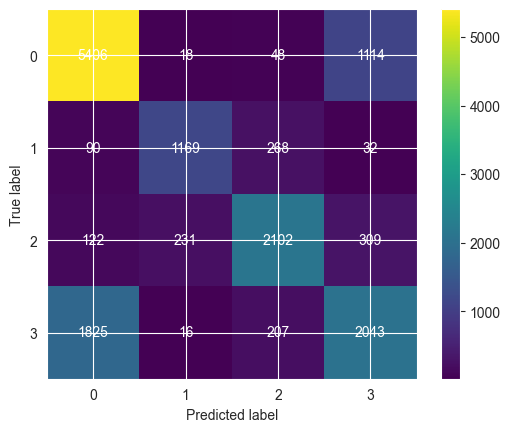

In [45]:
# Optional: Define display labels for clarity
# display_labels = ["Class 0", "Class 1"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
for text in disp.text_.flatten():
    text.set_color('white')

# Show the plot
plt.show()


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           1       0.73      0.82      0.77      6586
           2       0.82      0.75      0.78      1559
           3       0.80      0.76      0.78      2764
           4       0.58      0.50      0.54      4091

    accuracy                           0.71     15000
   macro avg       0.73      0.71      0.72     15000
weighted avg       0.71      0.71      0.71     15000



In [47]:
x_train.describe()

,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,browsing_time_minutes
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,36.449371,336.032571,4.876600,77.737171,61.311314
std,20.823666,201.424311,3.375117,71.552099,40.417869
min,1.000000,8.000000,0.000000,1.000000,1.000000
25%,18.000000,198.000000,3.000000,32.000000,33.000000
50%,37.000000,297.000000,4.000000,57.000000,53.000000
75%,55.000000,430.000000,6.000000,99.000000,80.000000
max,72.000000,3026.000000,68.000000,1289.000000,407.000000


In [48]:
scaler=StandardScaler()

In [49]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [50]:
model.fit(x_train_scaled,y_train)
y_predicts_scaled=model.predict(x_train_scaled)

In [51]:
accuracy_score(y_train, y_predicts_scaled)

0.9999714285714286

In [52]:
model=RandomForestClassifier(class_weight={1:1,2:1,3:1,4:2},n_estimators=300,max_features='sqrt',min_samples_leaf=4,min_samples_split=5,random_state=42)
model.fit(x_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
y_test_preds_scaled=model.predict(x_test_scaled)

In [54]:
accuracy_score(y_test,y_test_preds_scaled)

0.718

In [55]:
print(classification_report(y_test, y_test_preds_scaled))

              precision    recall  f1-score   support

           1       0.76      0.75      0.75      6586
           2       0.83      0.76      0.79      1559
           3       0.84      0.75      0.79      2764
           4       0.56      0.64      0.59      4091

    accuracy                           0.72     15000
   macro avg       0.75      0.72      0.73     15000
weighted avg       0.73      0.72      0.72     15000



In [56]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

search=RandomizedSearchCV(
    rf,
    params,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,

)

search.fit(x_train_scaled,y_train)

best_model=search.best_estimator_

In [57]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
df=customer_data

In [83]:
df['spend_per_visit']=df['avg_monthly_spend']/(df['purchase_frequency']+1)

In [84]:
df['value_per_order']=df['avg_monthly_spend']/(df['avg_order_value']+1)

In [85]:
df['engagement_score']=df['browsing_time_minutes']*df['purchase_frequency']

In [86]:
df['discount_impact']=df['discount_usage_rate']*df['avg_monthly_spend']

In [87]:
df['risk_score']=df['return_rate']*df['support_interactions']

In [88]:
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment,spend_per_visit,value_per_order,engagement_score,discount_impact,risk_score
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,2.0,Card,Semi-Urban,Occasional,60.500000,1.779412,77.0,12.1,0.0
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,2.0,Wallet,Urban,Occasional,143.250000,4.152174,276.0,171.9,0.8
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,1.0,UPI,Rural,Occasional,66.750000,3.657534,465.0,80.1,0.0
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,0.0,Wallet,Rural,High_Value,98.714286,6.457944,684.0,69.1,0.0
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,1.0,Card,Semi-Urban,Occasional,416.500000,2.339888,50.0,333.2,0.0


In [89]:
df=pd.get_dummies(df,columns=['payment_method','region'],drop_first=True)

In [90]:
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,...,customer_segment,spend_per_visit,value_per_order,engagement_score,discount_impact,risk_score,payment_method_UPI,payment_method_Wallet,region_Semi-Urban,region_Urban
0,33554,53,100473.0,63,121.0,1.0,67,0.1,0.0,77.0,...,Occasional,60.500000,1.779412,77.0,12.1,0.0,False,False,True,False
1,9428,54,54731.0,67,573.0,3.0,137,0.3,0.4,92.0,...,Occasional,143.250000,4.152174,276.0,171.9,0.8,False,True,False,True
2,200,44,58268.0,57,267.0,3.0,72,0.3,0.0,155.0,...,Occasional,66.750000,3.657534,465.0,80.1,0.0,True,False,False,False
3,12448,54,64830.0,40,691.0,6.0,106,0.1,0.4,114.0,...,High_Value,98.714286,6.457944,684.0,69.1,0.0,False,True,False,False
4,39490,28,27431.0,15,833.0,1.0,355,0.4,0.0,50.0,...,Occasional,416.500000,2.339888,50.0,333.2,0.0,False,False,True,False


In [91]:
mi=mutual_info_classif(df.drop(['customer_segment'],axis=1),df['customer_segment'])
mi_scores=pd.Series(mi,index=df.columns.drop(['customer_segment'])).sort_values(ascending=False)
mi_scores

value_per_order          0.242013
purchase_frequency       0.210284
spend_per_visit          0.201391
avg_order_value          0.163458
months_active            0.142355
engagement_score         0.133716
avg_monthly_spend        0.082819
discount_impact          0.044967
region_Urban             0.014328
browsing_time_minutes    0.007195
age                      0.003248
region_Semi-Urban        0.002534
discount_usage_rate      0.001565
customer_id              0.000946
annual_income            0.000747
payment_method_UPI       0.000502
support_interactions     0.000000
return_rate              0.000000
risk_score               0.000000
payment_method_Wallet    0.000000
dtype: float64

In [101]:
df=df[['value_per_order','purchase_frequency','spend_per_visit', 'avg_order_value', 'months_active','engagement_score','avg_monthly_spend','customer_segment']]

In [102]:
df.head()

,value_per_order,purchase_frequency,spend_per_visit,avg_order_value,months_active,engagement_score,avg_monthly_spend,customer_segment
0,1.779412,1.0,60.500000,67,63,77.0,121.0,Occasional
1,4.152174,3.0,143.250000,137,67,276.0,573.0,Occasional
2,3.657534,3.0,66.750000,72,57,465.0,267.0,Occasional
3,6.457944,6.0,98.714286,106,40,684.0,691.0,High_Value
4,2.339888,1.0,416.500000,355,15,50.0,833.0,Occasional


In [162]:
df['customer_segment']=le.fit_transform(df['customer_segment'])

In [163]:
df.head()

,value_per_order,purchase_frequency,spend_per_visit,avg_order_value,months_active,engagement_score,avg_monthly_spend,customer_segment
0,1.779412,1.0,60.500000,67,63,77.0,121.0,2
1,4.152174,3.0,143.250000,137,67,276.0,573.0,2
2,3.657534,3.0,66.750000,72,57,465.0,267.0,2
3,6.457944,6.0,98.714286,106,40,684.0,691.0,0
4,2.339888,1.0,416.500000,355,15,50.0,833.0,2


In [164]:
df.groupby('customer_segment').mean()

,value_per_order,purchase_frequency,spend_per_visit,avg_order_value,months_active,engagement_score,avg_monthly_spend
customer_segment,,,,,,,
0,9.204049,8.444149,60.174765,60.057273,54.298502,535.563626,463.749668
1,7.710908,6.733166,36.946482,35.891739,48.805522,408.251992,245.224381
2,4.197341,3.293727,111.468758,111.542630,29.569316,188.251210,381.574336
3,5.809018,4.807655,57.174275,56.271275,32.449275,307.234411,270.132293


In [165]:
df['high_value_order'] = df['avg_order_value'] * df['spend_per_visit']

In [166]:
df['engagement_vs_value'] = df['engagement_score'] / (df['avg_order_value'] + 1)

In [167]:
df['consistency_score'] = df['avg_monthly_spend'] / (df['purchase_frequency'] + 1)

In [168]:
df['engagement_per_month'] = df['engagement_score'] / (df['months_active'] + 1)

In [169]:
x_train1,x_test1,y_train1,y_test1=train_test_split(df.drop(['customer_segment'],axis=1),df['customer_segment'],test_size=0.3,random_state=0)


In [170]:
y_train1.head()

17967    2
32391    3
9341     3
7929     2
46544    2
Name: customer_segment, dtype: int64

In [171]:
y_train1.value_counts()

customer_segment
2    15455
3     9440
1     6416
0     3689
Name: count, dtype: int64

In [194]:
model=RandomForestClassifier(class_weight={0:1,1:1,2:1,3:3},n_estimators=300,max_features='sqrt',min_samples_leaf=4,min_samples_split=5,random_state=42)

In [173]:
model.fit(x_train1,y_train1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [175]:
y_preds1=model.predict(x_train1)
accuracy_score(y_train1,y_preds1)

0.8890857142857143

In [176]:
y_preds2=model.predict(x_test1)
accuracy_score(y_test1,y_preds2)

0.7254

In [177]:
print(classification_report(y_test1,y_preds2))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1584
           1       0.85      0.75      0.80      2747
           2       0.78      0.74      0.76      6654
           3       0.56      0.67      0.61      4015

    accuracy                           0.73     15000
   macro avg       0.76      0.73      0.74     15000
weighted avg       0.74      0.73      0.73     15000



In [178]:
scaler=StandardScaler()

In [179]:
x_train_scaled_new=scaler.fit_transform(x_train1)
x_test_scaled_new=scaler.fit_transform(x_test1)

In [195]:
model.fit(x_train_scaled_new,y_train1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [196]:
y_preds3=model.predict(x_train_scaled_new)
accuracy_score(y_train1,y_preds3)

0.8832285714285715

In [197]:
y_preds4=model.predict(x_test_scaled_new)
accuracy_score(y_test1,y_preds4)

0.7300666666666666

In [198]:
probs=model.predict_proba(x_test_scaled_new)
probs

array([[0.90183473, 0.07170062, 0.00838889, 0.01807576],
       [0.01624042, 0.00883785, 0.80151669, 0.17340504],
       [0.01590936, 0.0046645 , 0.61876566, 0.36066047],
       ...,
       [0.08384482, 0.8086571 , 0.02938146, 0.07811662],
       [0.00554385, 0.05362754, 0.32499174, 0.61583688],
       [0.5543704 , 0.39603967, 0.01475962, 0.03483031]], shape=(15000, 4))

In [199]:
y_pred_default = np.argmax(probs, axis=1)
y_pred_default

array([0, 2, 2, ..., 1, 3, 0], shape=(15000,))

In [200]:
y_pred_custom = []

threshold = 0.4

for i in range(len(probs)):
    if probs[i][3] > threshold:
        y_pred_custom.append(3)
    else:
        y_pred_custom.append(np.argmax(probs[i]))

In [203]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_custom = []

    for i in range(len(probs)):
        if probs[i][3] > t:
            y_pred_custom.append(3)
        else:
            y_pred_custom.append(np.argmax(probs[i]))

    print(f"\nThreshold: {t}")
    print(classification_report(y_test1, y_pred_custom))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1584
           1       0.85      0.75      0.79      2747
           2       0.85      0.48      0.62      6654
           3       0.47      0.86      0.61      4015

    accuracy                           0.66     15000
   macro avg       0.75      0.71      0.70     15000
weighted avg       0.75      0.66      0.66     15000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1584
           1       0.84      0.76      0.80      2747
           2       0.80      0.65      0.72      6654
           3       0.52      0.75      0.62      4015

    accuracy                           0.71     15000
   macro avg       0.76      0.72      0.73     15000
weighted avg       0.74      0.71      0.71     15000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86    

In [204]:
from sklearn.metrics import f1_score
import numpy as np

best_f1 = 0
best_t = 0

for t in np.arange(0.3, 0.7, 0.05):
    y_pred_custom = []

    for i in range(len(probs)):
        if probs[i][3] > t:
            y_pred_custom.append(3)
        else:
            y_pred_custom.append(np.argmax(probs[i]))

    f1 = f1_score(y_test1, y_pred_custom, average='weighted')

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.49999999999999994
Best F1: 0.7332331621139371


In [205]:
print(classification_report(y_test1,y_pred_custom))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1584
           1       0.83      0.78      0.80      2747
           2       0.77      0.76      0.77      6654
           3       0.57      0.64      0.61      4015

    accuracy                           0.73     15000
   macro avg       0.76      0.73      0.74     15000
weighted avg       0.74      0.73      0.73     15000



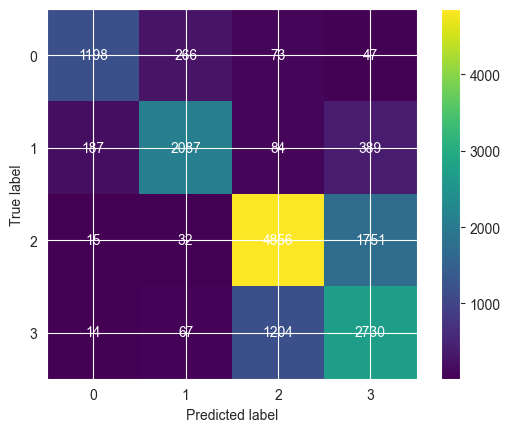

In [147]:
cm1=confusion_matrix(y_test1,y_preds4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
for text in disp.text_.flatten():
    text.set_color('white')

# Show the plot
plt.show()

In [154]:
customer_data.groupby['customer_segment'].mean()

TypeError: 'method' object is not subscriptable

In [148]:
from xgboost import XGBClassifier

In [156]:
model1=XGBClassifier(n_estimator=300,max_depth=6,learning_rate=0.1)


In [157]:
model1.fit(x_train_scaled_new,y_train1)

C:\Program Files\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:15:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [158]:
y_preds_xg=model1.predict(x_train_scaled_new)
accuracy_score(y_train1,y_preds_xg)

0.7682857142857142

In [160]:
y_preds_xgtest=model1.predict(x_test_scaled_new)
accuracy_score(y_test1,y_preds_xgtest)

0.7220666666666666

In [161]:
print(classification_report(y_test1,y_preds_xgtest))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      1584
           1       0.84      0.71      0.77      2747
           2       0.73      0.83      0.78      6654
           3       0.59      0.56      0.57      4015

    accuracy                           0.72     15000
   macro avg       0.76      0.70      0.72     15000
weighted avg       0.73      0.72      0.72     15000

